## Scattering simulation benchmarks

Selectively-runnable benchmarks comparing the `direct` and `fft` paths of
`BraggCoherentDiffraction.calculate_supercell_scattering`. Utilities live in
`aidino.benchmark`. Each test cell has a `RUN_THIS_TEST` flag at the top.

Sweeps recorded:
1. Time + memory of both methods vs supercell volume
2. Time + memory of direct method vs `q_batch_size`
3. Direct method time + memory + chi-squared error ($\chi^2_0$ vs direct@(1,1,1)) vs supercell volume
4. FFT method time + memory + chi-squared error ($\chi^2_0$ vs direct@(1,1,1), $\chi^2$ vs direct@same supercell) vs `fft_oversampling`
5. Time + memory of both methods vs `batch_size` (frames per call)

Each runs with and without sublattice displacements, using the relevant subset
of `grad_modes` per `include_sublattice` setting: `(no_grad, fwd_continuum,
bwd_continuum)` without sublattice, `(no_grad, fwd_sublattice, bwd_sublattice)`
with. For tests 3 and 4, chi^2 quantities are computed only under `no_grad`
(they are independent of `grad_mode`). OOM is trapped and recorded so partial
sweeps do not abort the rest. Results are saved to `benchmark_results/`.

In [1]:
import numpy as np
import torch

from aidino.benchmark import (
    BenchmarkResult,
    build_setup,
    make_supercell_grid,
    test_method_vs_supercells,
    test_method_vs_batch_size,
    test_direct_vs_qbatch,
    test_direct_error_vs_supercell,
    test_fft_error_vs_oversampling,
    save_results, load_results,
    plot_sweep,
    recommend_fft_oversampling,
    recommend_supercell_size
)

torch.set_default_dtype(torch.float32)
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}, {torch.cuda.get_device_name(device)}')

Device: cuda:0, NVIDIA RTX A5000


### Setup

Build one `BenchSetup` shared across all tests. Tune `crystal_size`,
`supercell_size`, `n_pixels` to your GPU budget. The displacement fields
are generated at unit-cell resolution and downsampled per test so the
supercell-size sweep does not require rebuilding them.

In [2]:
setup = build_setup(
    cif_path='../cifs/BaTiO3.cif',
    crystal_size=(48, 48, 48),
    supercell_size=(4, 4, 4),
    n_pixels=128,
    pixel_size=75e-6,
    distance=0.1,
    wavelength=1.5406e-10,
    seed=0,
    device=device,
    dtype=torch.float32,
)

print(f'Crystal_size: {setup.crystal_size}')
print(f'Supercell_size (default): {setup.supercell_size_default}')
print(f'Q_vectors shape: {tuple(setup.q_vectors.shape)}')
print(f'Bragg vector: {setup.bragg_vector.cpu().numpy() * 1e-9} nm^-1')
print(f'Recommended fft_oversampling: M = {recommend_fft_oversampling(setup)}')
print(f'Recommended supercell_size: d = {recommend_supercell_size(setup)}')

Auto beam entry: crystal -c face. beam_center = (24.0, 24.0, 0.5)
Crystal_size: (48, 48, 48)
Supercell_size (default): (4, 4, 4)
Q_vectors shape: (128, 128, 3)
Bragg vector: [22.305235  0.        0.      ] nm^-1
Recommended fft_oversampling: M = 12
Recommended supercell_size: d = (4, 4, 4)


### Test 1: Compute time + memory vs. supercell volume (both methods)

Sweeps `supercell_size`; swept value is the supercell volume in unit cells (`d1 * d2 * d3`).

In [3]:
supercell_grid = make_supercell_grid(setup.crystal_size, max_k=8)
print(f'supercell_grid: {supercell_grid}')
results_t1 = test_method_vs_supercells(
    setup,
    supercell_size_grid=supercell_grid,
    methods=('direct', 'fft'),
    include_sublattice_options=(False, True),
    q_batch_size=128,
    n_repeats=3
)
path = save_results(results_t1, 'method_vs_supercells')
print(f'saved to {path}')

supercell_grid: [(1, 1, 1), (2, 2, 2), (3, 3, 3), (4, 4, 4), (6, 6, 6), (8, 8, 8)]


method_vs_supercells: 100%|██████████| 72/72 [00:26<00:00,  2.68it/s]                         

saved to benchmark_results/method_vs_supercells_20260610_230427.json


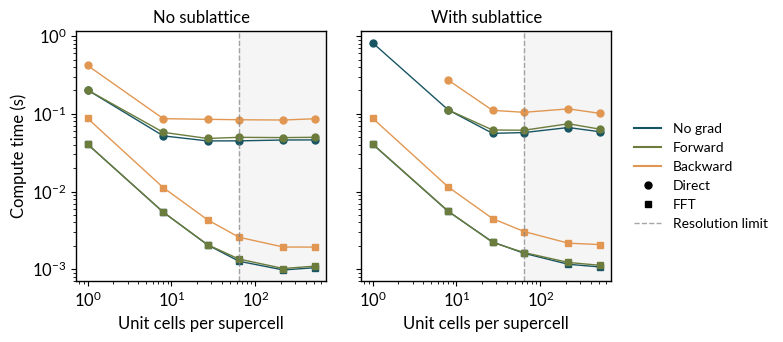

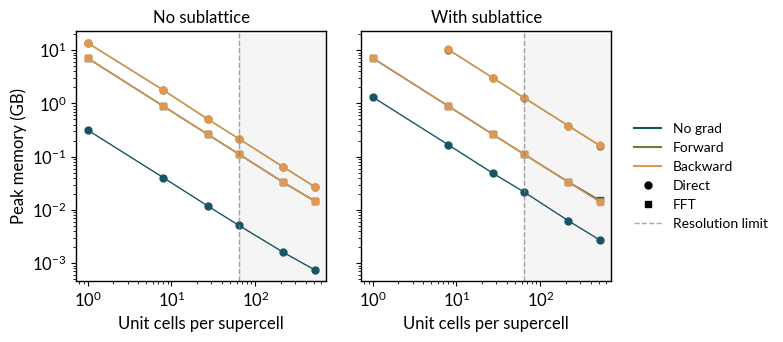

In [11]:
d_max = recommend_supercell_size(setup)
refs = [(d_max[0] * d_max[1] * d_max[2], 'Resolution limit', 'left')]
plot_sweep(results_t1, y='elapsed_time_s', group_by='method',
           facet_by='include_sublattice', vlines=refs)
plot_sweep(results_t1, y='peak_memory_gb', group_by='method',
           facet_by='include_sublattice', vlines=refs);

### Test 2: Compute time + memory of direct method vs q_batch_size

In [5]:
qbs_grid = [8, 16, 32, 64, 128, 256, 512, 1024]
results_t2 = test_direct_vs_qbatch(
    setup,
    q_batch_sizes=qbs_grid,
    include_sublattice_options=(False, True),
    n_repeats=3
)
path = save_results(results_t2, 'direct_vs_qbatch')
print(f'saved to {path}')

direct_vs_qbatch: 100%|██████████| 48/48 [00:58<00:00,  1.21s/it]                             

saved to benchmark_results/direct_vs_qbatch_20260610_230527.json


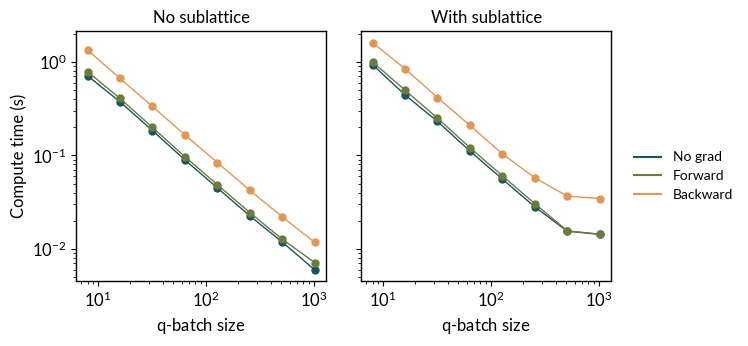

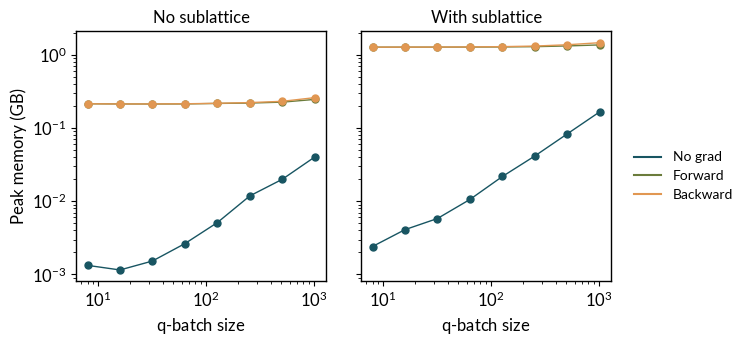

In [12]:
plot_sweep(results_t2, y='elapsed_time_s', group_by='method',
           facet_by='include_sublattice')
plot_sweep(results_t2, y='peak_memory_gb', group_by='method',
           facet_by='include_sublattice');

### Test 3: Direct method compute time + memory + error vs. supercell volume

Reference: `supercell_size=(1,1,1)` under `no_grad`. The chi-squared
metric matches Mokhtar et al. eq. 15 and is computed once per swept value
under `no_grad` (independent of `grad_mode`).

In [7]:
sc_grid = make_supercell_grid(setup.crystal_size, max_k=8)
print(f'sc_grid: {sc_grid}')
results_t3 = test_direct_error_vs_supercell(
    setup,
    supercell_sizes=sc_grid,
    include_sublattice_options=(False, True),
    q_batch_size=128,
    n_repeats=3
)
path = save_results(results_t3, 'direct_error_vs_supercell')
print(f'saved to {path}')

sc_grid: [(1, 1, 1), (2, 2, 2), (3, 3, 3), (4, 4, 4), (6, 6, 6), (8, 8, 8)]


direct_error_vs_supercell: 100%|██████████| 36/36 [00:22<00:00,  1.57it/s]                    

saved to benchmark_results/direct_error_vs_supercell_20260610_230551.json


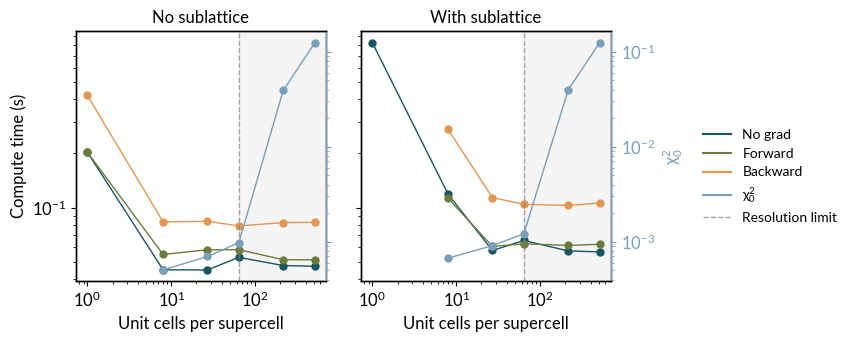

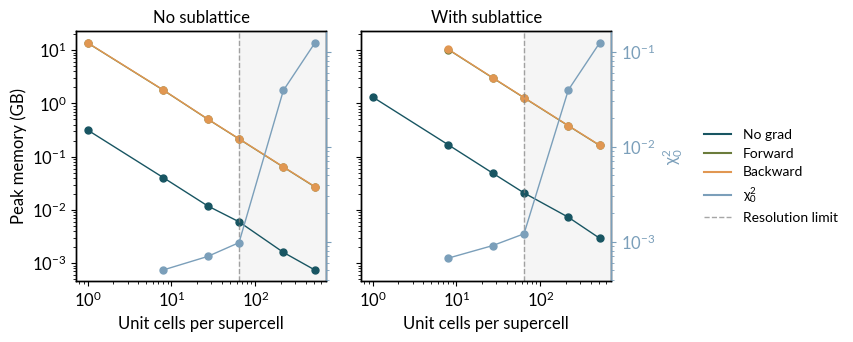

In [13]:
d_max = recommend_supercell_size(setup)
refs = [(d_max[0] * d_max[1] * d_max[2], 'Resolution limit', 'left')]
plot_sweep(results_t3, y='elapsed_time_s', y_twin='chi_squared_0',
           group_by='method', facet_by='include_sublattice', vlines=refs)
plot_sweep(results_t3, y='peak_memory_gb', y_twin='chi_squared_0',
           group_by='method', facet_by='include_sublattice', vlines=refs);

### Test 4: FFT method compute time + memory + error vs. FFT oversampling

Reference: Direct method at the same `supercell_size` under `no_grad`.
chi^2 is computed once per `M` under `no_grad` (independent of `grad_mode`).

In [9]:
M_grid = [1, 2, 4, 8, 12, 16, 32]
results_t4 = test_fft_error_vs_oversampling(
    setup,
    oversampling_factors=M_grid,
    include_sublattice_options=(False, True),
    q_batch_size=128,
    n_repeats=3
)
path = save_results(results_t4, 'fft_error_vs_oversampling')
print(f'saved to {path}')

fft_error_vs_oversampling: 100%|██████████| 42/42 [00:07<00:00,  5.38it/s]                    

saved to benchmark_results/fft_error_vs_oversampling_20260610_230600.json


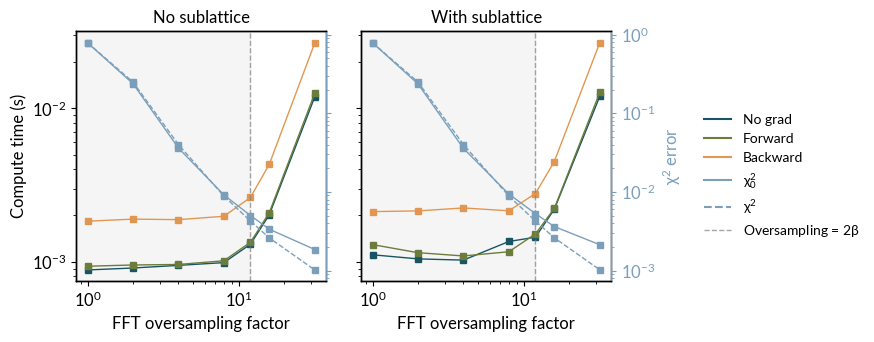

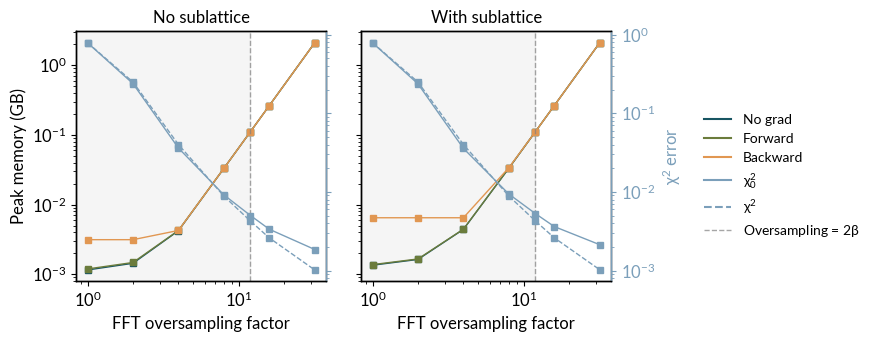

In [14]:
refs = [(recommend_fft_oversampling(setup), r'Oversampling = 2$\beta$', 'right')]
plot_sweep(results_t4, y='elapsed_time_s', y_twin=['chi_squared_0', 'chi_squared'],
           group_by='method', facet_by='include_sublattice', vlines=refs)
plot_sweep(results_t4, y='peak_memory_gb', y_twin=['chi_squared_0', 'chi_squared'],
           group_by='method', facet_by='include_sublattice', vlines=refs);

### Test 5: Compute time + memory vs. batch size (both methods)

Sweeps `batch_size` (the leading "frame" dimension of the displacement fields)
at fixed `supercell_size` and `q_batch_size`.

In [7]:
B_grid = [1, 4, 16, 64, 128]
results_t5 = test_method_vs_batch_size(
    setup,
    batch_sizes=B_grid,
    methods=('direct', 'fft'),
    include_sublattice_options=(False, True),
    q_batch_size=128,
    n_repeats=3,
)
path = save_results(results_t5, 'method_vs_batch_size')
print(f'saved to {path}')

method_vs_batch_size: 100%|██████████| 60/60 [00:39<00:00,  1.52it/s]                        

saved to benchmark_results/method_vs_batch_size_20260611_122219.json


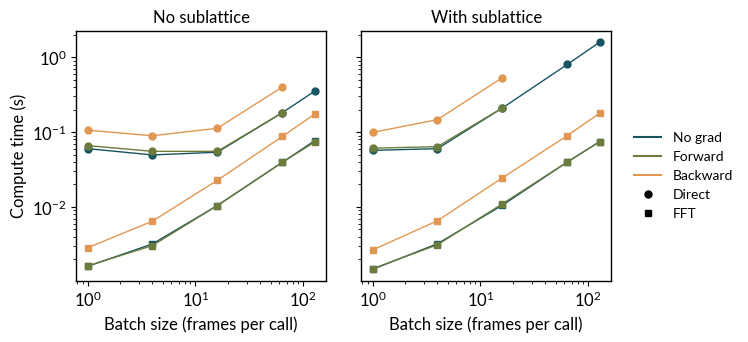

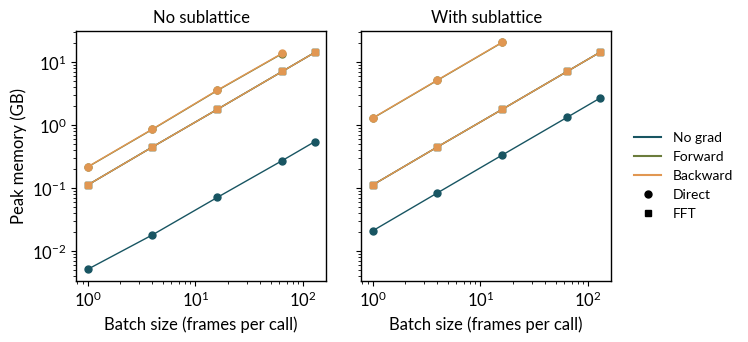

In [8]:
plot_sweep(results_t5, y='elapsed_time_s', group_by='method',
           facet_by='include_sublattice')
plot_sweep(results_t5, y='peak_memory_gb', group_by='method',
           facet_by='include_sublattice');

### Load and re-plot saved results

In [ ]:
# from pathlib import Path
# saved = sorted(Path('benchmark_results').glob('method_vs_supercells_*.json'))
# if saved:
#     results = load_results(saved[-1])
#     plot_sweep(results, y='elapsed_time_s', group_by='method',
#                facet_by='include_sublattice')